In [27]:
import pandas as pd

In [183]:
df = pd.read_csv('ecommerce.csv', parse_dates = ['Order_Date'], date_format = '%Y-%m-%d')

In [184]:
df.shape

(20, 11)

In [185]:
df.dtypes

Customer_ID               str
Name                      str
Age                   float64
Gender                    str
City                      str
Category                  str
Product                   str
Quantity                int64
Unit_Price            float64
Order_Date     datetime64[us]
Rating                float64
dtype: object

In [186]:
df.isnull().sum()

Customer_ID    0
Name           1
Age            1
Gender         0
City           0
Category       0
Product        0
Quantity       0
Unit_Price     0
Order_Date     0
Rating         2
dtype: int64

In [187]:
df[df.duplicated()]

,Customer_ID,Name,Age,Gender,City,Category,Product,Quantity,Unit_Price,Order_Date,Rating
3,C001,Nigel Baggar,25.0,Male,Harare,Electronics,Laptop,1,1200.0,2026-01-05,5.0
16,C003,Alice Dube,45.0,Female,Mutare,Food,Rice,5,2.0,2026-01-10,3.0


In [188]:
df.drop_duplicates(inplace=True, ignore_index=True)


In [189]:
df['Gender'] = df['Gender'].str.capitalize()
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Name'] = df['Name'].fillna('Unknown')

In [190]:
df

,Customer_ID,Name,Age,Gender,City,Category,Product,Quantity,Unit_Price,Order_Date,Rating
0,C001,Nigel Baggar,25.0,Male,Harare,Electronics,Laptop,1,1200.0,2026-01-05,5.0
1,C002,Tawana Moyo,32.0,Female,Bulawayo,Clothing,Jeans,2,60.0,2026-01-07,4.0
2,C003,Alice Dube,45.0,Female,Mutare,Food,Rice,5,2.0,2026-01-10,3.0
3,C004,Tryson Ncube,28.0,Male,Gweru,Electronics,Phone,1,800.0,2026-01-12,4.0
4,C005,Chido Mutasa,60.0,Female,Harare,Food,Bread,10,1.0,2026-01-15,2.0
5,C006,Unknown,35.0,Male,Bulawayo,Clothing,T-Shirt,3,25.0,2026-01-18,4.0
6,C007,Rudo Zimba,22.0,Female,Mutare,Electronics,Tablet,1,450.0,2026-01-20,5.0
7,C008,Tatenda Gomo,33.0,Male,Harare,Electronics,Laptop,2,1200.0,2026-01-22,4.0
8,C009,Farai Moyo,29.0,Female,Gweru,Clothing,Dress,1,80.0,2026-01-25,3.0
9,C010,Tinashe Ndlovu,67.0,Male,Bulawayo,Food,Sugar,20,0.5,2026-02-01,4.0


In [191]:
import re
df[df['Name'].apply(lambda x: bool(re.search(r'[^\x00-\x7F]', str(x))))]

,Customer_ID,Name,Age,Gender,City,Category,Product,Quantity,Unit_Price,Order_Date,Rating
17,C018,礼Gomo,27.0,Female,Mutare,Clothing,Dress,2,80.0,2026-03-01,4.0


In [192]:
df['Name'] = df['Name'].apply(lambda x: re.sub(r'[^\x00-\x7F]', '', str(x)))

In [193]:
df = df.assign(Revenue = df['Unit_Price'] * df['Quantity'])
df.insert(9, 'Revenue', df.pop('Revenue'))

In [194]:
top_customers = df.groupby('Name')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
top_customers.head(3)

,Name,Revenue
12,Tatenda Gomo,2400.0
7,Nigel Baggar,1200.0
1,Bensaviuor Sky,900.0


In [195]:
top_category = df.groupby('Category')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
top_category.head(1)

,Category,Revenue
1,Electronics,7350.0


In [196]:
category_rating = df.groupby('Category')['Rating'].mean().round(1).reset_index().sort_values(by='Rating', ascending=False)
category_rating

,Category,Rating
1,Electronics,4.4
0,Clothing,3.8
2,Food,3.0


In [197]:
df = df.set_index('Order_Date')
monthly_trend = (df.resample('ME')['Revenue'].sum().reset_index()
                   .assign(Order_Date= lambda x: x['Order_Date'].dt.strftime('%b-%Y'))
                    )
monthly_trend

,Order_Date,Revenue
0,Jan-2026,5145.0
1,Feb-2026,2846.0
2,Mar-2026,160.0


In [212]:
city_order = (df.groupby('City')['Quantity'].sum().round(1).reset_index().
           sort_values(by='Quantity', ascending=False)
           .rename(columns = {'Quantity': 'Orders'})
       )
city_order.head(1)

,City,Orders
2,Harare,31


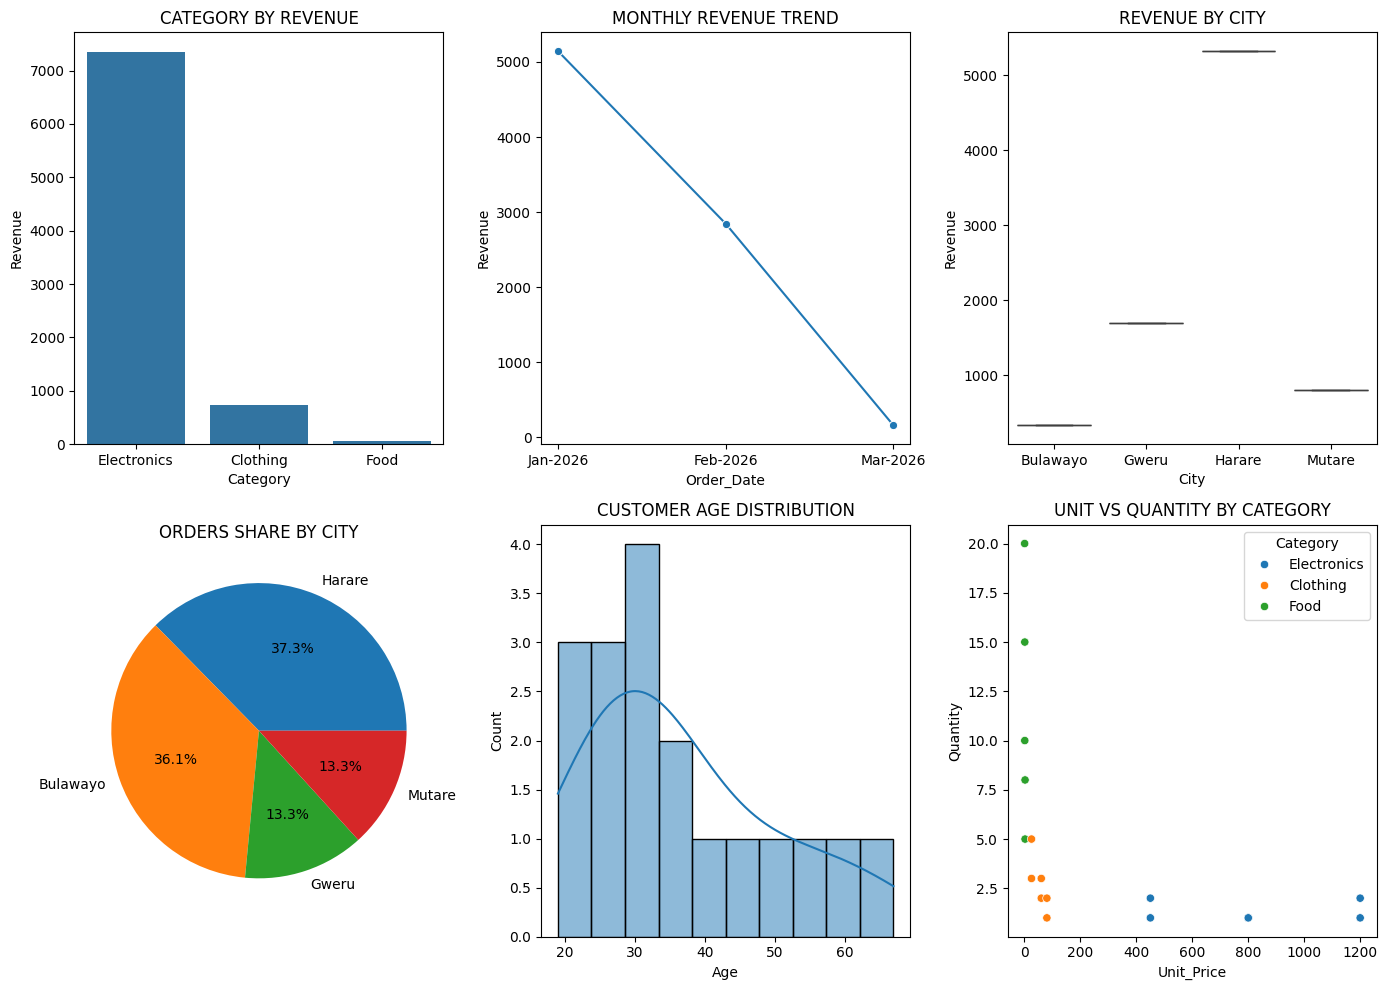

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2,3, figsize=(14,10))

sns.barplot(data=top_category, x='Category', y='Revenue', ax= axes[0,0])
axes[0,0].set_title('CATEGORY BY REVENUE')   

sns.lineplot(data=monthly_trend, x='Order_Date', y='Revenue', marker='o', ax=axes[0,1])
axes[0,1].set_title("MONTHLY REVENUE TREND")

axes[1,0].pie(city_order['Orders'], labels= city_order['City'], autopct = '%1.1f%%')
axes[1,0].set_title('ORDERS SHARE BY CITY')

sns.histplot(df['Age'], bins=10, kde=True, ax=axes[1,1])
axes[1,1].set_title("CUSTOMER AGE DISTRIBUTION")

sns.scatterplot(data=df, x='Unit_Price', y='Quantity', hue='Category', ax=axes[1, 2])
axes[1, 2].set_title('UNIT VS QUANTITY BY CATEGORY')

city_rev = df.groupby('City')['Revenue'].sum().reset_index()
sns.boxplot(data=city_rev, x='City', y = 'Revenue', ax=axes[0, 2])
axes[0, 2].set_title('REVENUE BY CITY')    

plt.tight_layout()
plt.show()

In [221]:
def generate_report(df, monthly_trend, top_customers,category_rating):
    corr_PriceQuantity = df['Unit_Price'].corr(df['Quantity'], method='pearson')
    
    overall = pd.DataFrame([
        {"Metric": "Total Revenue", "Result":f"${df['Revenue'].sum():,.2f}"},
        {"Metric": "Top Category by Revenue", "Result":df.groupby('Category')['Revenue'].sum().idxmax()},
        {"Metric": "City with most Orders", "Result":df.groupby('City')['Quantity'].sum().idxmax()},
        {"Metric": "Best Month by Revenue", "Result": monthly_trend.loc[monthly_trend['Revenue'].idxmax(),'Order_Date']},
        {"Metric": "City with Most Revenue", "Result":df.groupby('City')['Revenue'].sum().idxmax()},
        {"Metric": "Correlation (Unit_Price vs Quantity)", "Result": f"{corr_PriceQuantity:.2f}"}

        
    ])

    
    top_3 = top_customers.head(3).copy()
    top_3.columns = ['Metric', 'Result']

    category = category_rating.copy()
    category.columns = ['Metric', 'Result']

    trend = monthly_trend.copy()
    trend.columns = ['Metric', 'Result']

    
    
    report = pd.concat([overall, 
                        pd.DataFrame([{"Metric": "---TOP 3 CUSTOMERS BY SPENDING---", "Result": ""}]),
                        top_3,
                        pd.DataFrame([{"Metric": "---CATEGORIES WITH MOST RATING---", "Result": ""}]),
                        category,
                        pd.DataFrame([{"Metric": "---MONTHLY REVENUE TREND---", "Result": ""}]),
                        trend
                        
                        ], ignore_index=True)
    
    report.to_csv("E_COMMERCE.csv", index=False)
    return report

generate_report(df, monthly_trend, top_customers,category_rating)

,Metric,Result
0,Total Revenue,"$8,151.00"
1,Top Category by Revenue,Electronics
2,City with most Orders,Harare
3,Best Month by Revenue,Jan-2026
4,City with Most Revenue,Harare
5,Correlation (Unit_Price vs Quantity),-0.49
6,---TOP 3 CUSTOMERS BY SPENDING---,
7,Tatenda Gomo,2400.0
8,Nigel Baggar,1200.0
9,Bensaviuor Sky,900.0
